In [1]:
import pandas as pd
import numpy as np
import time
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

os.makedirs('../results/final', exist_ok=True)
os.makedirs('../results/final/figures', exist_ok=True)

LABEL_MAP   = {0: 'Benign', 1: 'DoS', 2: 'DDoS', 3: 'Mirai', 4: 'Spoofing'}
CLASS_NAMES = ['Benign', 'DoS', 'DDoS', 'Mirai', 'Spoofing']
MODELS      = ['DT', 'RF', 'XGB', 'LGBM', 'CAT', 'BRF']

print("All imports successful.")

All imports successful.


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nClass distribution (train):\n{y_train.value_counts().sort_index().rename(LABEL_MAP)}")
print(f"\nClass distribution (test):\n{y_test.value_counts().sort_index().rename(LABEL_MAP)}")

X_train: (1062114, 30)
X_test:  (265529, 30)

Class distribution (train):
Label_encoded
Benign      318298
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64

Class distribution (test):
Label_encoded
Benign      79574
DoS         59940
DDoS        59774
Mirai       34851
Spoofing    31390
Name: count, dtype: int64


In [3]:
# Stage 1 — binary labels
y_train_binary = y_train.apply(lambda x: 'Benign' if x == 0 else 'Attack')
y_test_binary  = y_test.apply(lambda x: 'Benign' if x == 0 else 'Attack')

le_binary = LabelEncoder()
y_train_binary_enc = le_binary.fit_transform(y_train_binary)
y_test_binary_enc  = le_binary.transform(y_test_binary)
print(f"Binary encoding: {dict(zip(le_binary.classes_, le_binary.transform(le_binary.classes_)))}")

# Stage 2 — attack-only rows
attack_mask_train = y_train != 0
attack_mask_test  = y_test != 0
X_train_attack    = X_train[attack_mask_train]
y_train_attack    = y_train[attack_mask_train]
X_test_attack     = X_test[attack_mask_test]
y_test_attack     = y_test[attack_mask_test]

le_attack = LabelEncoder()
y_train_attack_enc = le_attack.fit_transform(y_train_attack)
y_test_attack_enc  = le_attack.transform(y_test_attack)
print(f"Attack encoding: {dict(zip(le_attack.classes_, le_attack.transform(le_attack.classes_)))}")

print(f"\nStage 2 class distribution (train):\n{y_train_attack.value_counts().sort_index().rename(LABEL_MAP)}")

Binary encoding: {'Attack': np.int64(0), 'Benign': np.int64(1)}
Attack encoding: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}

Stage 2 class distribution (train):
Label_encoded
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64


In [4]:
stage1_models = {
    'DT':   DecisionTreeClassifier(random_state=42),
    'RF':   RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGB':  XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    'LGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'CAT':  CatBoostClassifier(random_state=42, verbose=0),
    'BRF':  BalancedRandomForestClassifier(random_state=42, n_jobs=-1,
                                            n_estimators=50, max_depth=20)
}

stage1_results = {}
stage1_preds   = {}
stage1_fitted  = {}

for name, model in stage1_models.items():
    print(f"\n{'='*50}")
    print(f"Stage 1: {name}")
    print(f"{'='*50}")
    t0 = time.time()
    model.fit(X_train, y_train_binary_enc)
    train_time = time.time() - t0

    # train accuracy for overfitting check
    train_acc = accuracy_score(y_train_binary_enc, model.predict(X_train))

    y_pred_enc = model.predict(X_test)
    y_pred     = le_binary.inverse_transform(y_pred_enc)
    stage1_preds[name]  = y_pred
    stage1_fitted[name] = model

    acc  = accuracy_score(y_test_binary, y_pred)
    prec = precision_score(y_test_binary, y_pred, pos_label='Attack')
    rec  = recall_score(y_test_binary, y_pred, pos_label='Attack')
    f1   = f1_score(y_test_binary, y_pred, pos_label='Attack')
    cm   = confusion_matrix(y_test_binary, y_pred, labels=['Benign', 'Attack'])
    fnr  = cm[1][0] / (cm[1][0] + cm[1][1])

    stage1_results[name] = {
        'train_accuracy': train_acc, 'accuracy': acc,
        'precision': prec, 'recall': rec, 'f1': f1,
        'confusion_matrix': cm.tolist(),
        'false_negative_rate': fnr,
        'overfit_gap': train_acc - acc,
        'train_time_sec': train_time
    }

    print(f"Train Acc: {train_acc:.4f} | Test Acc: {acc:.4f} | Overfit Gap: {train_acc-acc:.4f}")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | FNR: {fnr:.4f}")
    print(f"Train time: {train_time:.1f}s")

print("\n✓ Stage 1 complete.")


Stage 1: DT
Train Acc: 0.9958 | Test Acc: 0.8928 | Overfit Gap: 0.1031
Precision: 0.9220 | Recall: 0.9251 | F1: 0.9236 | FNR: 0.0749
Train time: 15.2s

Stage 1: RF
Train Acc: 0.9958 | Test Acc: 0.9050 | Overfit Gap: 0.0908
Precision: 0.9378 | Recall: 0.9257 | F1: 0.9317 | FNR: 0.0743
Train time: 46.4s

Stage 1: XGB
Train Acc: 0.9096 | Test Acc: 0.9088 | Overfit Gap: 0.0009
Precision: 0.9539 | Recall: 0.9140 | F1: 0.9335 | FNR: 0.0860
Train time: 2.2s

Stage 1: LGBM
Train Acc: 0.8983 | Test Acc: 0.8985 | Overfit Gap: -0.0002
Precision: 0.9442 | Recall: 0.9088 | F1: 0.9262 | FNR: 0.0912
Train time: 2.6s

Stage 1: CAT
Train Acc: 0.9175 | Test Acc: 0.9157 | Overfit Gap: 0.0018
Precision: 0.9609 | Recall: 0.9169 | F1: 0.9384 | FNR: 0.0831
Train time: 61.3s

Stage 1: BRF
Train Acc: 0.9189 | Test Acc: 0.9098 | Overfit Gap: 0.0090
Precision: 0.9870 | Recall: 0.8829 | F1: 0.9320 | FNR: 0.1171
Train time: 21.6s

✓ Stage 1 complete.


In [5]:
stage2_models = {
    'DT':   DecisionTreeClassifier(random_state=42),
    'RF':   RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGB':  XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'CAT':  CatBoostClassifier(random_state=42, verbose=0),
    'BRF':  BalancedRandomForestClassifier(random_state=42, n_jobs=-1,
                                            n_estimators=50, max_depth=20)
}

stage2_results = {}
stage2_preds   = {}
stage2_fitted  = {}
labels_present = sorted(y_test_attack.unique())

for name, model in stage2_models.items():
    print(f"\n{'='*50}")
    print(f"Stage 2: {name}")
    print(f"{'='*50}")
    t0 = time.time()
    model.fit(X_train_attack, y_train_attack_enc)
    train_time = time.time() - t0

    train_acc  = accuracy_score(y_train_attack_enc, model.predict(X_train_attack))
    y_pred_enc = model.predict(X_test_attack)
    y_pred     = le_attack.inverse_transform(y_pred_enc)
    stage2_preds[name]  = y_pred
    stage2_fitted[name] = model

    acc  = accuracy_score(y_test_attack, y_pred)
    prec = precision_score(y_test_attack, y_pred, average='macro')
    rec  = recall_score(y_test_attack, y_pred, average='macro')
    f1   = f1_score(y_test_attack, y_pred, average='macro')

    stage2_results[name] = {
        'train_accuracy': train_acc, 'accuracy': acc,
        'precision_macro': prec, 'recall_macro': rec, 'f1_macro': f1,
        'overfit_gap': train_acc - acc,
        'train_time_sec': train_time
    }

    print(f"Train Acc: {train_acc:.4f} | Test Acc: {acc:.4f} | Overfit Gap: {train_acc-acc:.4f}")
    print(f"Macro F1: {f1:.4f} | Train time: {train_time:.1f}s")
    print(classification_report(y_test_attack, y_pred,
                                 target_names=[LABEL_MAP[l] for l in labels_present]))

print("\n✓ Stage 2 complete.")


Stage 2: DT
Train Acc: 0.9953 | Test Acc: 0.8654 | Overfit Gap: 0.1299
Macro F1: 0.8449 | Train time: 10.7s
              precision    recall  f1-score   support

         DoS       0.88      0.88      0.88     59940
        DDoS       0.96      0.96      0.96     59774
       Mirai       0.74      0.74      0.74     34851
    Spoofing       0.80      0.80      0.80     31390

    accuracy                           0.87    185955
   macro avg       0.85      0.84      0.84    185955
weighted avg       0.87      0.87      0.87    185955


Stage 2: RF
Train Acc: 0.9952 | Test Acc: 0.8830 | Overfit Gap: 0.1122
Macro F1: 0.8667 | Train time: 34.8s
              precision    recall  f1-score   support

         DoS       0.91      0.88      0.89     59940
        DDoS       0.97      0.96      0.96     59774
       Mirai       0.76      0.81      0.78     34851
    Spoofing       0.82      0.84      0.83     31390

    accuracy                           0.88    185955
   macro avg       0.

In [6]:
hierarchical_results = {}
hierarchical_preds   = {}
y_test_arr = y_test.values
all_labels = sorted(LABEL_MAP.keys())

for name in MODELS:
    final_pred = np.empty(len(y_test), dtype=object)
    benign_idx = np.where(stage1_preds[name] == 'Benign')[0]
    attack_idx = np.where(stage1_preds[name] == 'Attack')[0]

    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_enc = stage2_fitted[name].predict(X_test.iloc[attack_idx])
        final_pred[attack_idx] = le_attack.inverse_transform(s2_enc)

    final_pred = final_pred.astype(int)
    hierarchical_preds[name] = final_pred

    acc         = accuracy_score(y_test_arr, final_pred)
    prec_macro  = precision_score(y_test_arr, final_pred, average='macro')
    rec_macro   = recall_score(y_test_arr, final_pred, average='macro')
    f1_macro    = f1_score(y_test_arr, final_pred, average='macro')
    f1_weighted = f1_score(y_test_arr, final_pred, average='weighted')
    cm          = confusion_matrix(y_test_arr, final_pred, labels=all_labels)
    fnr         = np.sum((y_test_arr != 0) & (final_pred == 0)) / np.sum(y_test_arr != 0)

    hierarchical_results[name] = {
        'accuracy': acc, 'precision_macro': prec_macro,
        'recall_macro': rec_macro, 'f1_macro': f1_macro,
        'f1_weighted': f1_weighted, 'confusion_matrix': cm.tolist(),
        'labels': CLASS_NAMES, 'false_negative_rate': fnr
    }

    print(f"\n=== {name} === Acc: {acc:.4f} | F1: {f1_macro:.4f} | FNR: {fnr:.4f}")

print("\n✓ Combined pipeline complete.")


=== DT === Acc: 0.8172 | F1: 0.7876 | FNR: 0.0749

=== RF === Acc: 0.8398 | F1: 0.8137 | FNR: 0.0743

=== XGB === Acc: 0.8459 | F1: 0.8158 | FNR: 0.0860

=== LGBM === Acc: 0.8330 | F1: 0.8013 | FNR: 0.0912

=== CAT === Acc: 0.8528 | F1: 0.8236 | FNR: 0.0831

=== BRF === Acc: 0.8599 | F1: 0.8295 | FNR: 0.1171

✓ Combined pipeline complete.


In [7]:
print("\n=== Cross-Model: RF Stage 1 + BRF Stage 2 ===")

final_pred_cross = np.empty(len(y_test), dtype=object)
benign_idx = np.where(stage1_preds['RF'] == 'Benign')[0]
attack_idx = np.where(stage1_preds['RF'] == 'Attack')[0]

final_pred_cross[benign_idx] = 0
if len(attack_idx) > 0:
    s2_enc = stage2_fitted['BRF'].predict(X_test.iloc[attack_idx])
    final_pred_cross[attack_idx] = le_attack.inverse_transform(s2_enc)

final_pred_cross = final_pred_cross.astype(int)

acc_cross  = accuracy_score(y_test_arr, final_pred_cross)
prec_cross = precision_score(y_test_arr, final_pred_cross, average='macro')
rec_cross  = recall_score(y_test_arr, final_pred_cross, average='macro')
f1_cross   = f1_score(y_test_arr, final_pred_cross, average='macro')
f1w_cross  = f1_score(y_test_arr, final_pred_cross, average='weighted')
cm_cross   = confusion_matrix(y_test_arr, final_pred_cross, labels=all_labels)
fnr_cross  = np.sum((y_test_arr != 0) & (final_pred_cross == 0)) / np.sum(y_test_arr != 0)

cross_result = {
    'accuracy': acc_cross, 'precision_macro': prec_cross,
    'recall_macro': rec_cross, 'f1_macro': f1_cross,
    'f1_weighted': f1w_cross, 'confusion_matrix': cm_cross.tolist(),
    'labels': CLASS_NAMES, 'false_negative_rate': fnr_cross
}

print(f"Accuracy: {acc_cross:.4f} | Macro F1: {f1_cross:.4f} | FNR: {fnr_cross:.4f}")
print(classification_report(y_test_arr, final_pred_cross, target_names=CLASS_NAMES))


=== Cross-Model: RF Stage 1 + BRF Stage 2 ===
Accuracy: 0.8461 | Macro F1: 0.8230 | FNR: 0.0743
              precision    recall  f1-score   support

      Benign       0.83      0.86      0.84     79574
         DoS       0.95      0.83      0.89     59940
        DDoS       0.98      0.96      0.97     59774
       Mirai       0.70      0.80      0.74     34851
    Spoofing       0.65      0.68      0.67     31390

    accuracy                           0.85    265529
   macro avg       0.82      0.83      0.82    265529
weighted avg       0.85      0.85      0.85    265529



In [8]:
print(f"\n{'='*70}")
print(f"FINAL RESULTS — HIERARCHICAL PIPELINE")
print(f"{'='*70}")
print(f"{'Setup':<30} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12} {'FNR':>8}")
print(f"{'-'*70}")

for name in MODELS:
    r = hierarchical_results[name]
    marker = ' ← best F1' if name == 'BRF' else (' ← best FNR' if name == 'RF' else '')
    print(f"{'Same-model '+name:<30} "
          f"{r['accuracy']:>10.4f} "
          f"{r['f1_macro']:>10.4f} "
          f"{r['f1_weighted']:>12.4f} "
          f"{r['false_negative_rate']:>8.4f}{marker}")

print(f"{'-'*70}")
print(f"{'Cross: RF S1 + BRF S2':<30} "
      f"{acc_cross:>10.4f} "
      f"{f1_cross:>10.4f} "
      f"{f1w_cross:>12.4f} "
      f"{fnr_cross:>8.4f} ← best balanced")


FINAL RESULTS — HIERARCHICAL PIPELINE
Setup                            Accuracy   Macro F1  Weighted F1      FNR
----------------------------------------------------------------------
Same-model DT                      0.8172     0.7876       0.8172   0.0749
Same-model RF                      0.8398     0.8137       0.8402   0.0743 ← best FNR
Same-model XGB                     0.8459     0.8158       0.8453   0.0860
Same-model LGBM                    0.8330     0.8013       0.8326   0.0912
Same-model CAT                     0.8528     0.8236       0.8520   0.0831
Same-model BRF                     0.8599     0.8295       0.8569   0.1171 ← best F1
----------------------------------------------------------------------
Cross: RF S1 + BRF S2              0.8461     0.8230       0.8485   0.0743 ← best balanced


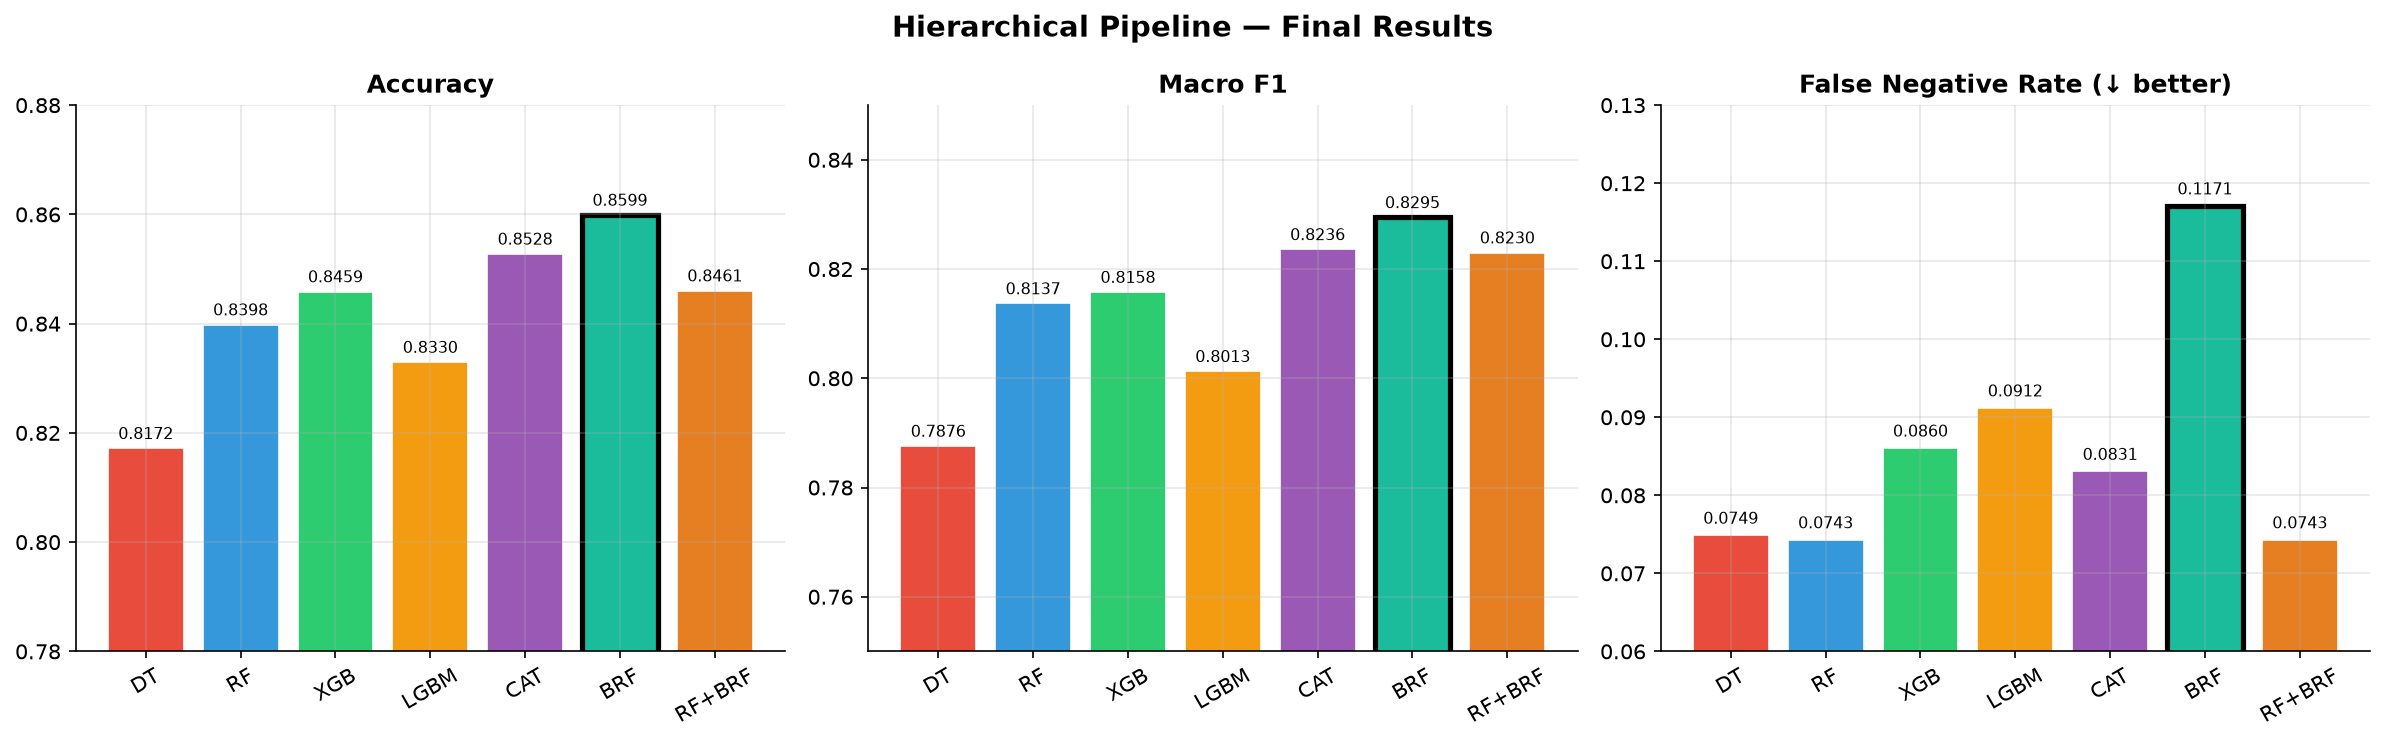

Saved: 01_final_comparison.png


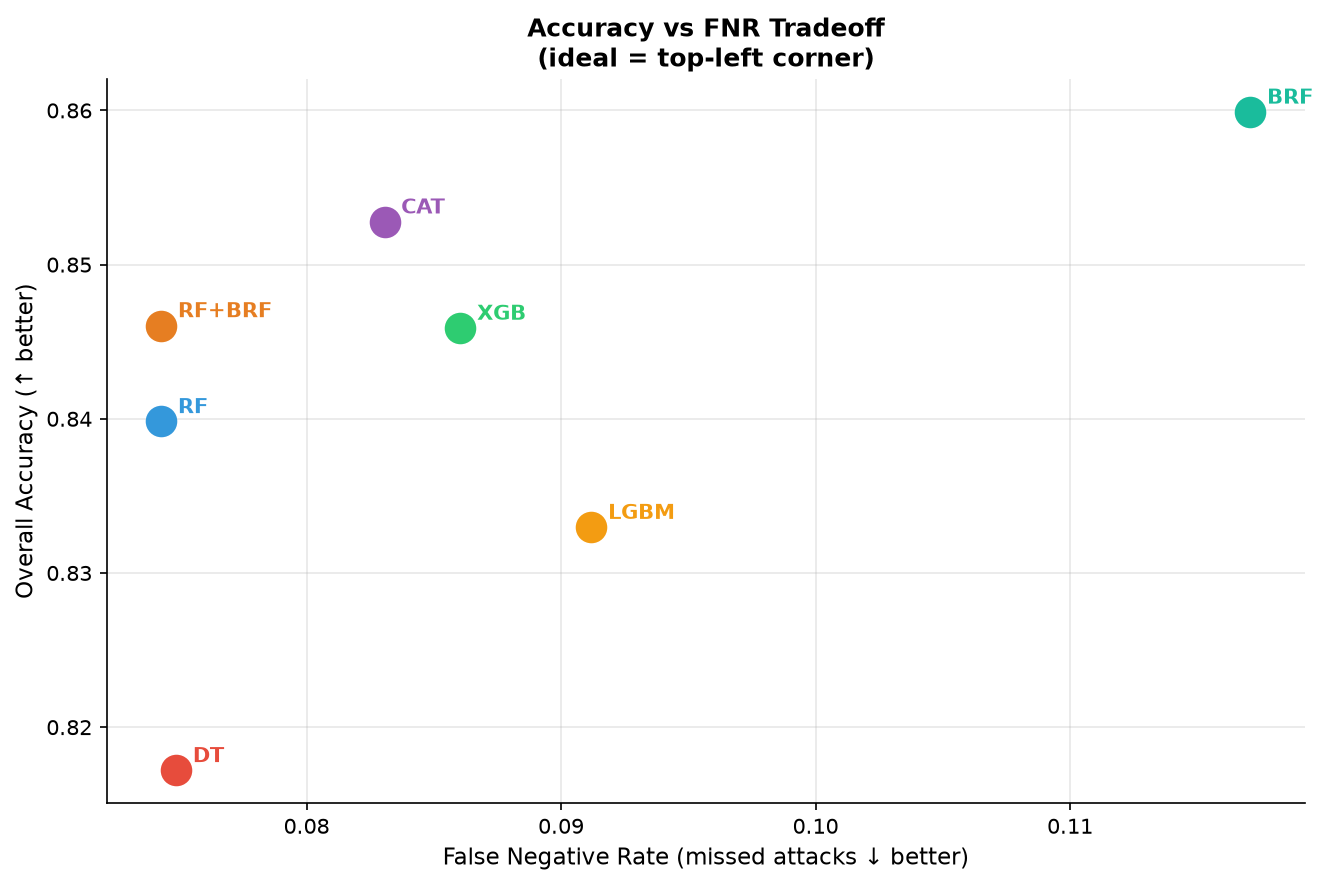

Saved: 02_accuracy_vs_fnr.png


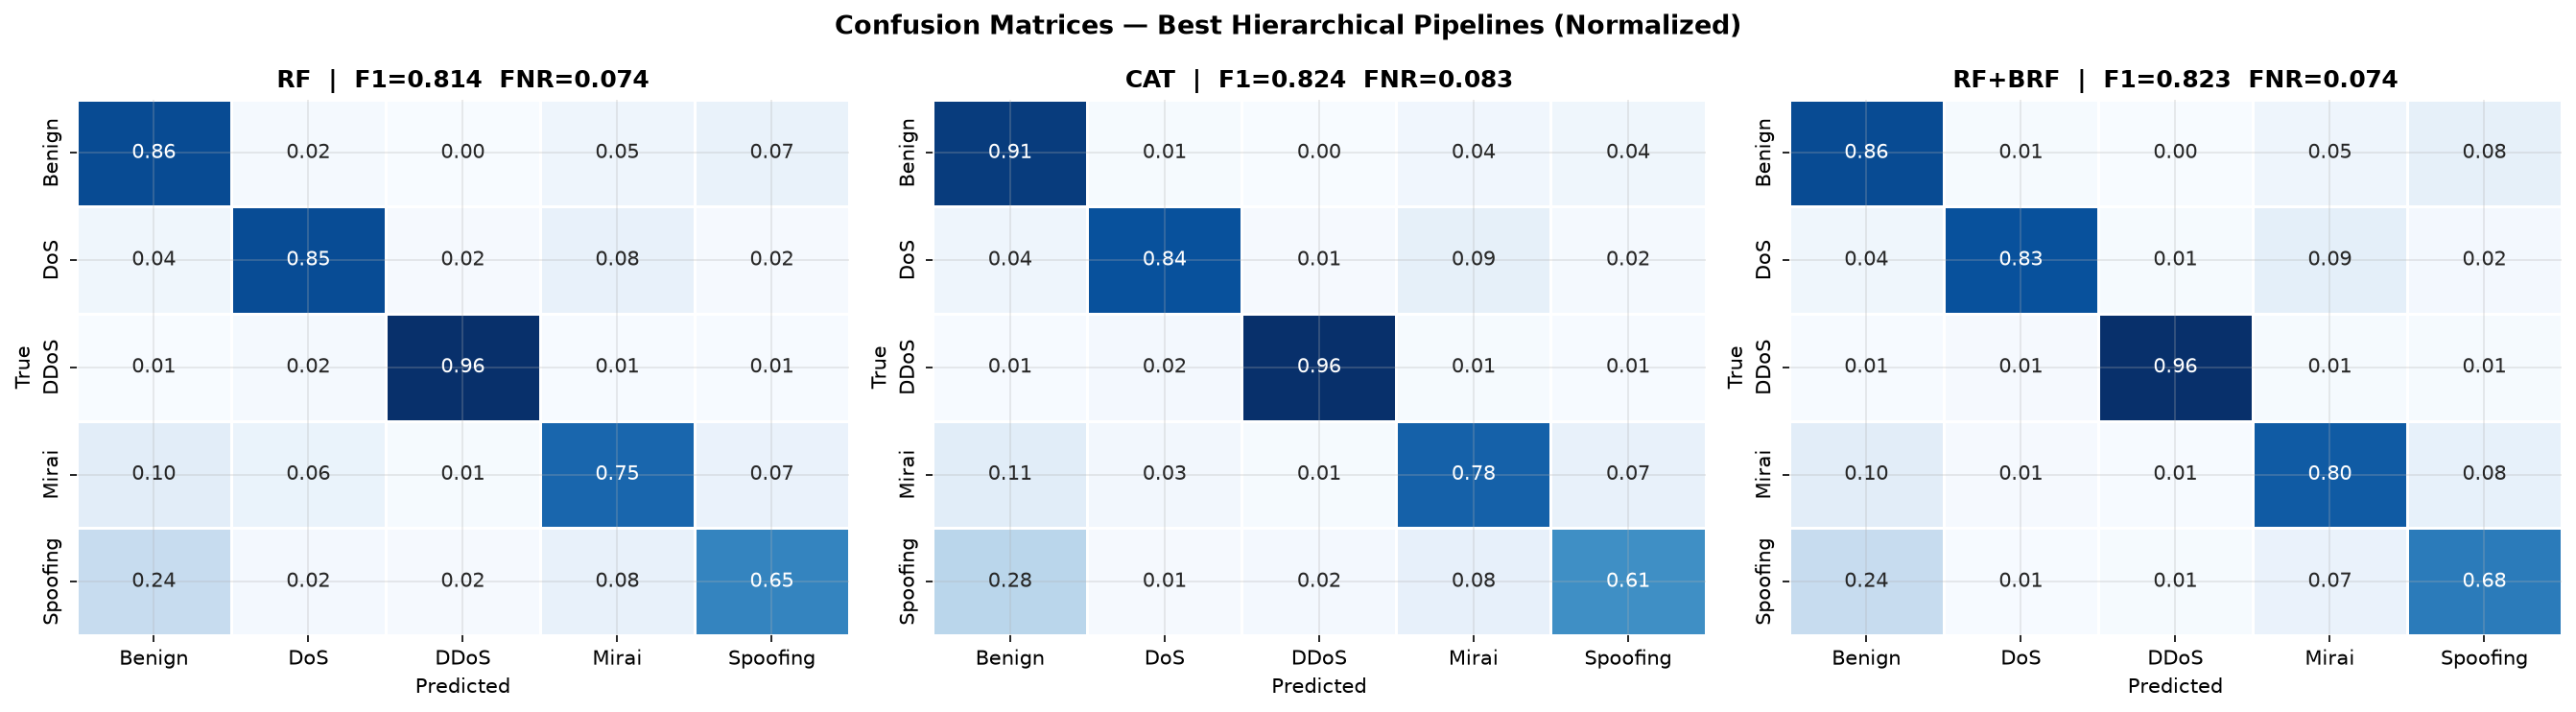

Saved: 03_confusion_matrices.png


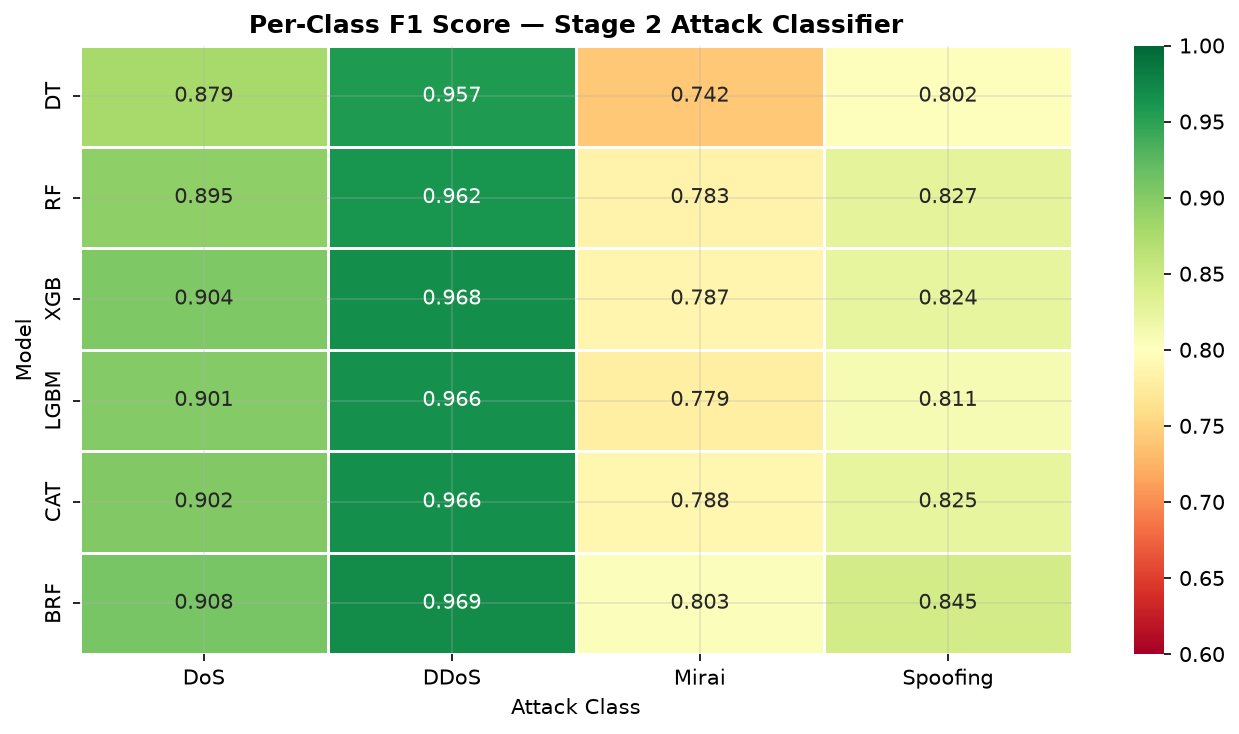

Saved: 04_perclass_f1_heatmap.png


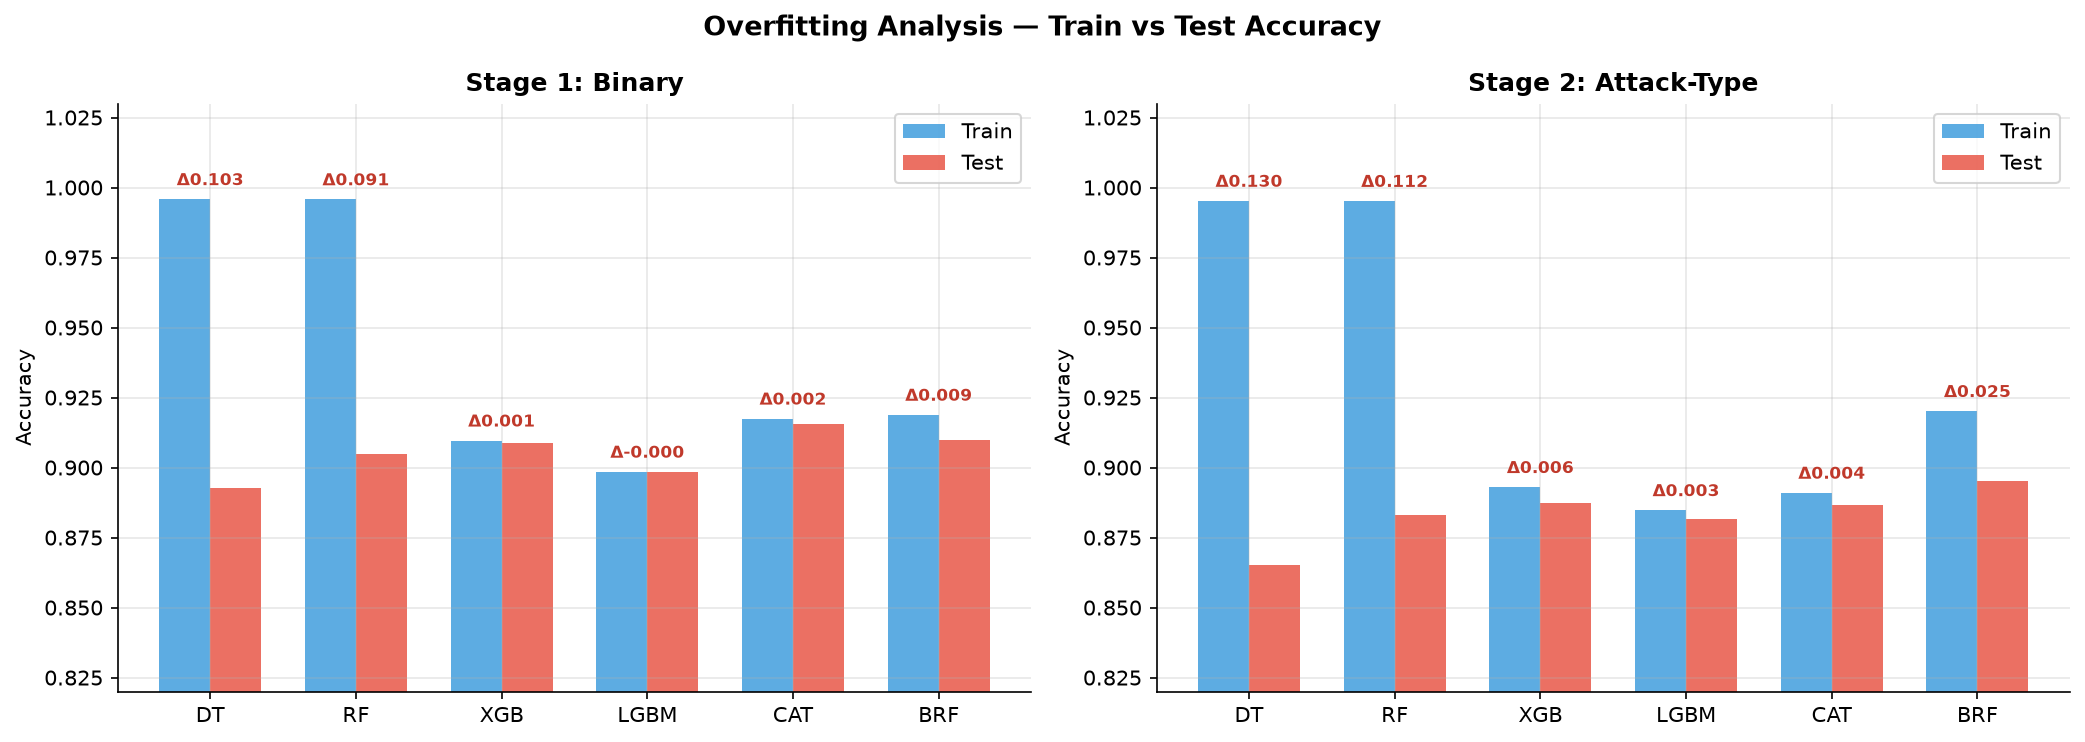

Saved: 05_overfitting.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

PALETTE = {
    'DT': '#e74c3c', 'RF': '#3498db', 'XGB': '#2ecc71',
    'LGBM': '#f39c12', 'CAT': '#9b59b6', 'BRF': '#1abc9c',
    'RF+BRF': '#e67e22'
}

all_names  = MODELS + ['RF+BRF']
all_acc    = [hierarchical_results[m]['accuracy'] for m in MODELS] + [acc_cross]
all_f1     = [hierarchical_results[m]['f1_macro'] for m in MODELS] + [f1_cross]
all_fnr    = [hierarchical_results[m]['false_negative_rate'] for m in MODELS] + [fnr_cross]
all_colors = [PALETTE[m] for m in all_names]

# ── Fig 1: Accuracy / F1 / FNR bar charts ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hierarchical Pipeline — Final Results', fontsize=14, fontweight='bold')

for ax, vals, title, ylim in zip(
    axes,
    [all_acc, all_f1, all_fnr],
    ['Accuracy', 'Macro F1', 'False Negative Rate (↓ better)'],
    [(0.78, 0.88), (0.75, 0.85), (0.06, 0.13)]
):
    bars = ax.bar(all_names, vals, color=all_colors, edgecolor='white', linewidth=0.8)
    ax.set_ylim(ylim)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    best = np.argmin(vals) if 'FNR' in title else np.argmax(vals)
    bars[best].set_edgecolor('black')
    bars[best].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('../results/final/figures/01_final_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: 01_final_comparison.png")


# ── Fig 2: Accuracy vs FNR scatter ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for name, acc, fnr in zip(all_names, all_acc, all_fnr):
    ax.scatter(fnr, acc, color=PALETTE[name], s=200, zorder=5)
    ax.annotate(name, (fnr, acc), textcoords='offset points',
                xytext=(8, 4), fontsize=10, fontweight='bold', color=PALETTE[name])

ax.set_xlabel('False Negative Rate (missed attacks ↓ better)', fontsize=11)
ax.set_ylabel('Overall Accuracy (↑ better)', fontsize=11)
ax.set_title('Accuracy vs FNR Tradeoff\n(ideal = top-left corner)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/final/figures/02_accuracy_vs_fnr.png', bbox_inches='tight')
plt.show()
print("Saved: 02_accuracy_vs_fnr.png")


# ── Fig 3: Normalized confusion matrices (best 3 models) ────────────────────
best_models = [('RF', hierarchical_results['RF']['confusion_matrix']),
               ('CAT', hierarchical_results['CAT']['confusion_matrix']),
               ('RF+BRF', cm_cross.tolist())]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Best Hierarchical Pipelines (Normalized)',
             fontsize=13, fontweight='bold')

for ax, (name, cm_list) in zip(axes, best_models):
    cm = np.array(cm_list)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    r = cross_result if name == 'RF+BRF' else hierarchical_results[name]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(f'{name}  |  F1={r["f1_macro"]:.3f}  FNR={r["false_negative_rate"]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('../results/final/figures/03_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: 03_confusion_matrices.png")


# ── Fig 4: Per-class F1 heatmap across all models (Stage 2) ─────────────────
attack_classes = ['DoS', 'DDoS', 'Mirai', 'Spoofing']
per_class_f1 = {}

for name in MODELS:
    y_pred = stage2_preds[name]
    labels = sorted(y_test_attack.unique())
    cm = confusion_matrix(y_test_attack, y_pred, labels=labels)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    prec = np.where((tp+fp)>0, tp/(tp+fp), 0)
    rec  = np.where((tp+fn)>0, tp/(tp+fn), 0)
    f1   = np.where((prec+rec)>0, 2*prec*rec/(prec+rec), 0)
    per_class_f1[name] = f1

f1_matrix = np.array([per_class_f1[m] for m in MODELS])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=attack_classes, yticklabels=MODELS,
            ax=ax, vmin=0.6, vmax=1.0, linewidths=0.5)
ax.set_title('Per-Class F1 Score — Stage 2 Attack Classifier', fontweight='bold')
ax.set_xlabel('Attack Class')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('../results/final/figures/04_perclass_f1_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: 04_perclass_f1_heatmap.png")


# ── Fig 5: Overfitting analysis ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting Analysis — Train vs Test Accuracy', fontsize=13, fontweight='bold')

for ax, (stage_data, title) in zip(axes, [
    (stage1_results, 'Stage 1: Binary'),
    (stage2_results, 'Stage 2: Attack-Type')
]):
    train_accs = [stage_data[m]['train_accuracy'] for m in MODELS]
    test_accs  = [stage_data[m]['accuracy'] for m in MODELS]
    x = np.arange(len(MODELS))
    w = 0.35
    ax.bar(x - w/2, train_accs, w, label='Train', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, test_accs,  w, label='Test',  color='#e74c3c', alpha=0.8)
    for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
        ax.text(i, max(tr, te) + 0.005, f'Δ{tr-te:.3f}',
                ha='center', fontsize=8, color='#c0392b', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylim(0.82, 1.03)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/final/figures/05_overfitting.png', bbox_inches='tight')
plt.show()
print("Saved: 05_overfitting.png")

In [10]:
def make_json_safe(d):
    if isinstance(d, dict):  return {k: make_json_safe(v) for k, v in d.items()}
    if isinstance(d, list):  return [make_json_safe(v) for v in d]
    if isinstance(d, (np.integer,)):  return int(d)
    if isinstance(d, (np.floating,)): return float(d)
    return d

all_results = {
    'stage1_binary':         make_json_safe(stage1_results),
    'stage2_attack_type':    make_json_safe(stage2_results),
    'hierarchical_combined': make_json_safe(hierarchical_results),
    'cross_model_RF_BRF': {
        'accuracy':            acc_cross,
        'precision_macro':     prec_cross,
        'recall_macro':        rec_cross,
        'f1_macro':            f1_cross,
        'f1_weighted':         f1w_cross,
        'false_negative_rate': fnr_cross,
        'confusion_matrix':    cm_cross.tolist(),
        'labels':              CLASS_NAMES
    }
}

with open('../results/final/hierarchical_final_results.json', 'w') as f:
    json.dump(make_json_safe(all_results), f, indent=2)

print("✓ All results saved to ../results/final/hierarchical_final_results.json")
print("✓ All figures saved to ../results/final/figures/")

✓ All results saved to ../results/final/hierarchical_final_results.json
✓ All figures saved to ../results/final/figures/


In [11]:
from scipy import stats

seeds = [42, 123, 456, 789, 1000]

# ── Comparison 1: RF vs BRF at Stage 2 ──────────────────────────────────────
print("Running Stage 2: RF vs BRF across 5 seeds...")
print("(this will take a while)")

rf_s2_scores  = []
brf_s2_scores = []

for seed in seeds:
    print(f"  Seed {seed}...")

    # RF Stage 2
    rf_temp = RandomForestClassifier(random_state=seed, n_jobs=-1)
    rf_temp.fit(X_train_attack, y_train_attack_enc)
    y_pred = le_attack.inverse_transform(rf_temp.predict(X_test_attack))
    rf_s2_scores.append(f1_score(y_test_attack, y_pred, average='macro'))

    # BRF Stage 2
    brf_temp = BalancedRandomForestClassifier(random_state=seed, n_jobs=-1,
                                               n_estimators=50, max_depth=20)
    brf_temp.fit(X_train_attack, y_train_attack_enc)
    y_pred = le_attack.inverse_transform(brf_temp.predict(X_test_attack))
    brf_s2_scores.append(f1_score(y_test_attack, y_pred, average='macro'))

t_stat, p_value = stats.ttest_rel(rf_s2_scores, brf_s2_scores)
print(f"\n── Stage 2: RF vs BRF ──────────────────────────")
print(f"RF  mean F1: {np.mean(rf_s2_scores):.4f} ± {np.std(rf_s2_scores):.4f}")
print(f"BRF mean F1: {np.mean(brf_s2_scores):.4f} ± {np.std(brf_s2_scores):.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")
print(f"Significant (p<0.05): {'Yes ✓' if p_value < 0.05 else 'No ✗'}")


# ── Comparison 2: Flat RF vs Hierarchical RF (full pipeline) ─────────────────
print("\nRunning Flat RF vs Hierarchical RF across 5 seeds...")

flat_rf_scores = []
hier_rf_scores = []

for seed in seeds:
    print(f"  Seed {seed}...")

    rf_temp = RandomForestClassifier(random_state=seed, n_jobs=-1)

    # Flat — train on all 5 classes directly
    rf_temp.fit(X_train, y_train)
    y_pred_flat = rf_temp.predict(X_test)
    flat_rf_scores.append(f1_score(y_test, y_pred_flat, average='macro'))

    # Hierarchical — Stage 1
    rf_s1_temp = RandomForestClassifier(random_state=seed, n_jobs=-1)
    rf_s1_temp.fit(X_train, y_train_binary_enc)
    s1_pred = le_binary.inverse_transform(rf_s1_temp.predict(X_test))

    # Hierarchical — Stage 2
    rf_s2_temp = RandomForestClassifier(random_state=seed, n_jobs=-1)
    rf_s2_temp.fit(X_train_attack, y_train_attack_enc)

    final_pred = np.empty(len(y_test), dtype=object)
    benign_idx = np.where(s1_pred == 'Benign')[0]
    attack_idx = np.where(s1_pred == 'Attack')[0]
    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_enc = rf_s2_temp.predict(X_test.iloc[attack_idx])
        final_pred[attack_idx] = le_attack.inverse_transform(s2_enc)
    final_pred = final_pred.astype(int)

    hier_rf_scores.append(f1_score(y_test.values, final_pred, average='macro'))

t_stat2, p_value2 = stats.ttest_rel(flat_rf_scores, hier_rf_scores)
print(f"\n── Flat RF vs Hierarchical RF ──────────────────")
print(f"Flat mean F1: {np.mean(flat_rf_scores):.4f} ± {np.std(flat_rf_scores):.4f}")
print(f"Hier mean F1: {np.mean(hier_rf_scores):.4f} ± {np.std(hier_rf_scores):.4f}")
print(f"t-statistic:  {t_stat2:.4f}")
print(f"p-value:      {p_value2:.4f}")
print(f"Significant (p<0.05): {'Yes ✓' if p_value2 < 0.05 else 'No ✗'}")

Running Stage 2: RF vs BRF across 5 seeds...
(this will take a while)
  Seed 42...
  Seed 123...
  Seed 456...
  Seed 789...
  Seed 1000...

── Stage 2: RF vs BRF ──────────────────────────
RF  mean F1: 0.8667 ± 0.0001
BRF mean F1: 0.8820 ± 0.0004
t-statistic: -86.1353
p-value:     0.0000
Significant (p<0.05): Yes ✓

Running Flat RF vs Hierarchical RF across 5 seeds...
  Seed 42...
  Seed 123...
  Seed 456...
  Seed 789...
  Seed 1000...

── Flat RF vs Hierarchical RF ──────────────────
Flat mean F1: 0.8142 ± 0.0001
Hier mean F1: 0.8136 ± 0.0001
t-statistic:  7.4696
p-value:      0.0017
Significant (p<0.05): Yes ✓


In [12]:
import joblib
import os

os.makedirs('../results/models', exist_ok=True)

for name, model in stage1_fitted.items():
    joblib.dump(model, f'../results/models/hier_stage1_{name}.pkl')
    print(f"Saved: hier_stage1_{name}.pkl")

for name, model in stage2_fitted.items():
    joblib.dump(model, f'../results/models/hier_stage2_{name}.pkl')
    print(f"Saved: hier_stage2_{name}.pkl")

print("\nAll models saved successfully")

Saved: hier_stage1_DT.pkl
Saved: hier_stage1_RF.pkl
Saved: hier_stage1_XGB.pkl
Saved: hier_stage1_LGBM.pkl
Saved: hier_stage1_CAT.pkl
Saved: hier_stage1_BRF.pkl
Saved: hier_stage2_DT.pkl
Saved: hier_stage2_RF.pkl
Saved: hier_stage2_XGB.pkl
Saved: hier_stage2_LGBM.pkl
Saved: hier_stage2_CAT.pkl
Saved: hier_stage2_BRF.pkl

All models saved successfully
